У нас есть датасет lenta.ru с новостями за Сентябрь 1999 - декабрь 2019. Датасет состоит из 6 столбцов: url, заголовка, текста самой статьи, топика и тага (да-да, это разные вещи) и даты.


In [ ]:
! unzip lenta-ru-news.csv.zip

Archive:  lenta-ru-news.csv.zip
  inflating: lenta-ru-news.csv       


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('lenta-ru-news.csv')
df.head()

/tmp/ipykernel_648/3943795599.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('lenta-ru-news.csv')


,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,Первая мировая,1914/09/18


In [ ]:
x = df['topic'].value_counts().reset_index()
x

,topic,count
0,Россия,160445
1,Мир,136621
2,Экономика,79528
3,Спорт,64413
4,Культура,53797
5,Бывший СССР,53402
6,Наука и техника,53136
7,Интернет и СМИ,44663
8,Из жизни,27605
9,Дом,21734


In [ ]:
y = df['tags'].value_counts().reset_index()
y

,tags,count
0,Все,453762
1,Политика,40716
2,Общество,35202
3,Украина,22523
4,Происшествия,19825
...,...,...
89,Мировой опыт,6
90,Нацпроекты,6
91,Вооружение,3
92,Инновации,1


Немного порывшись на самом сайте ленты.ру можно узнать разницу между этими двумя вещами: топик - это первое разделение всех нововстей, таг - подразделение каждого топика. Именно поэтому тага 'Все' так много, это сборная солянка по всем топикам.

Так как и топиков и тагов слишком много для пет-проекта с ограниченным гпу, я беру топ-5 топиков. **Суть проекта - определить, к какой теме относится статья на основе хедера и самой статьи.**

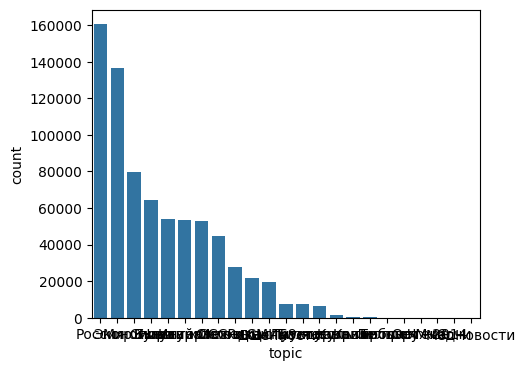

In [ ]:
plt.figure(figsize=(5, 4))
sns.barplot(x='topic' , y = 'count', data=x)
plt.show()

Оставим топ-5 топиков

In [ ]:
h = x.head()
lis = list( h['topic'])

In [ ]:
df = df[df['topic'].isin(lis)]

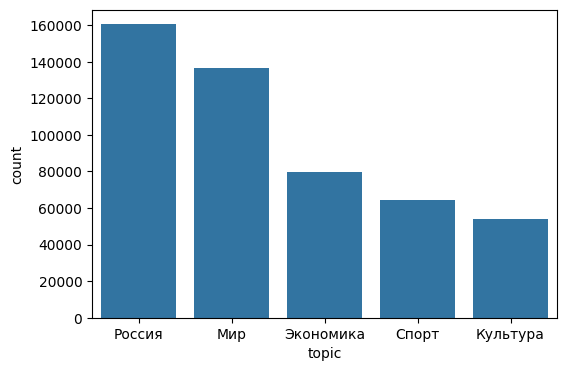

In [ ]:
plt.figure(figsize=(6, 4))

x = df['topic'].value_counts().reset_index()
sns.barplot(x='topic' , y = 'count', data=x)
plt.show()

Уберем лишние признаки, заранее отсортировав по дате

In [ ]:
df = df.sort_values(by='date')
df = df.drop(['url', 'date', 'tags'], axis=1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/cleaned.csv', index=False, encoding='utf-8')

In [ ]:
df.head()

,title,text,topic
5,"Космонавты сомневаются в надежности ""Мира""",Как стало известно агентству Ассошиэйтед Пресс...,Россия
21,Референдум по вопросу о самоопределении Восточ...,"По сведениям миссии ООН, передаваемым РИА ""Нов...",Мир
20,Литва засудила участников переворота 91 года,Россия крайне негативно оценивает судебный про...,Мир
19,Киргизия ведет бои на границах с Таджикистаном...,"На юге Киргизии, а именно в Баткенском и Чон-А...",Мир
18,Российские национал-большевики убирают террито...,15 представителей национал-большевистской парт...,Мир


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 494804 entries, 5 to 739175
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   title   494804 non-null  object
 1   text    494799 non-null  object
 2   topic   494804 non-null  object
dtypes: object(3)
memory usage: 15.1+ MB


In [ ]:
df_3 = df.copy()
df['textt'] = df['title'] + " " + df['text']

df = df.drop(['title', 'text'], axis=1)

**Итоговый датасет, с которым мы будем работать**

In [ ]:
df.to_csv('/content/drive/MyDrive/cleaned2.csv', index=False, encoding='utf-8')

In [ ]:
df.iloc[347209, 1]

'Обыск в\xa0офисе Навального провели по\xa0делу «Ив Роше» Выемка документов в «Фонде борьбы с коррупцией» Алексея Навального была связана с делом о мошеннических действиях, которые оппозиционер, по версии следствия, совершил в отношении компании «Ив Роше». Об этом «Ленте.ру» сообщил адвокат Навального Вадим Кобзев. Какие именно документы заинтересовали следователей, Кобзев не уточнил. Сотрудники СК пришли в фонд Навального около 16 часов 9 июля. Навальный написал в твиттере, что следователи не планируют изымать подписи муниципальных депутатов, собранные предвыборным штабом для выдвижения оппозиционера в мэры Москвы. «Выемка в рамках одного из дел против меня», — добавил он. По версии следствия, Алексей Навальный и его брат Олег навязали «Ив Роше» услуги своей компании «Главное подписное агентство» по заведомо завышенной цене, нанеся продавцу косметики ущерб на 55 миллионов рублей. При этом до 2012 года сотрудничество «Ив Роше» с «Главподпиской» продолжалось около трех лет и никаких пре